# Tutorial: Bayesian Statistics Lab: Priors, Model Selection, and Posterior Inference

Federico Cerutti <federico.cerutti@unibs.it>

The notes are released with CC0. The code is MIT.

**Format of this notebook.** This notebook is designed as a self-guided lab. The code cells are intentionally compact and should be treated as the validated reference implementation. The teaching material therefore lives in the markdown: read the text first, inspect the code second, and only then run the cell.



**Useful references for students who want a formal API reference**
- [PyMC documentation](https://www.pymc.io/projects/docs/en/stable/learn.html)
- [ArviZ documentation](https://python.arviz.org/en/stable/)
- [SciPy statistical tests](https://docs.scipy.org/doc/scipy/reference/stats.html)
- [statsmodels power analysis](https://www.statsmodels.org/stable/stats.html#power-and-sample-size)

**Main take-away for this lab**
- In the examples below, Bayesian analysis is more informative for decision making because it returns full uncertainty distributions and directly interpretable probabilities, not only a reject / fail-to-reject decision.


## 0. Environment setup and reading strategy


- The first code cell installs missing packages in a Colab-friendly way.
- The second code cell imports the libraries, fixes the global seed, and creates the random number generator used throughout the notebook.

As you read the import cell, classify the libraries by role:
- **classical statistics** (`scipy`, `statsmodels`),
- **Bayesian modeling and diagnostics** (`pymc`, `arviz`),
- **data handling and plotting** (`pandas`, `numpy`, `matplotlib`).


In [1]:
# Colab-friendly install cell.
# It only installs packages that are missing in the current runtime.
import subprocess
import sys

required = ["pymc", "arviz", "statsmodels"]
# ArviZ — works hand-in-hand with PyMC. After sampling, ArviZ gives you summaries (az.summary()), diagnostic plots, and model comparison (az.compare() with LOO). Think of it as the "results viewer" for PyMC.
# PyMC — this is the most important library to understand. It lets you define probabilistic models and sample from posteriors using NUTS (a modern MCMC algorithm). You'll see the with pm.Model() pattern everywhere.

import importlib.util
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print({"missing_before_install": missing, "required": required})


{'missing_before_install': [], 'required': ['pymc', 'arviz', 'statsmodels']}


In [2]:
from __future__ import annotations

import os
import random
import warnings
from math import lgamma

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats
from scipy.stats import beta as beta_dist, gamma as gamma_dist
from statsmodels.stats.power import TTestIndPower

warnings.filterwarnings("ignore")
az.style.use("arviz-whitegrid")


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [3]:
# One global seed for deterministic notebook output.
SEED = 42

# SET SEED FOR OS ENVIRONMENT VARIABLES
os.environ["PYTHONHASHSEED"] = str(SEED)

# SET SEED FOR PYTHON'S BUILT-IN RANDOM MODULE
random.seed(SEED) # random.seed(SEED) sets the seed for Python's built-in random number generator, which is used by the random module. This ensures that any random operations performed using this module will produce the same results each time the code is run, as long as the seed is set to the same value.

# SET SEED FOR NUMPY'S RANDOM NUMBER GENERATOR (2 WAYS)
np.random.seed(SEED) # np.random.seed(SEED) sets the seed for NumPy's random number generator, which is used for any random operations performed using NumPy (e.g., np.random.rand, np.random.normal). This ensures that any random numbers generated by NumPy will be the same each time the code is run, as long as the seed is set to the same value.
RNG = np.random.default_rng(SEED) # RNG = np.random.default_rng(SEED) creates a new random number generator instance using NumPy's newer random API. 
# This is a more modern and flexible way to generate random numbers compared to the older np.random functions. By passing the seed to default_rng, you ensure that this specific generator will produce the same sequence of random numbers each time the code is run, as long as the seed is the same.

print({"seed": SEED})

{'seed': 42}


## 2. Simulated binary classifier outputs: indistinguishable versus distinguishable

We now study the binary outputs of two classifiers on the same batch of items. For pedagogical simplicity, we only keep the outputs themselves, not the features that produced them, so the modeling question stays clean: do the two classifiers behave the same, or do they have different positive-output rates?

The Bayesian comparison has two stories:
- **indistinguishable classifiers**: one shared Bernoulli rate;
- **distinguishable classifiers**: each classifier gets its own Bernoulli rate.

The code below computes the corresponding Beta posteriors, the posterior probability that classifier 2 has the higher positive-output rate, and the Bayes factor between the two stories. A worked multi-class Dirichlet extension follows below.

**Before running the next cell**
- Find the two simulated rates in the code.
- Locate the lines where the shared and separate posteriors are updated.
- Predict whether the distinguishable model should win.


In [4]:
# Simulated binary outputs from two classifiers.
# Use local RNGs so this section does not change the later notebook examples.
classifier_rng = np.random.default_rng(SEED + 101)
posterior_rng = np.random.default_rng(SEED + 102)

In [5]:
# GENERATE SYNTHETIC DATA FOR TWO CLASSIFIERS

n_1 = 60 # observations for classifier 1
n_2 = 60 # observations for classifier 2
theta_1_true = 0.60 # The true positive-output rate for classifier 1. In a real experiment, this would be unknown and what we're trying to infer by Bayesian comparison of the two classifiers.
theta_2_true = 0.78 # The true positive-output rate for classifier 2. In a real experiment, this would be unknown and what we're trying to infer by Bayesian comparison of the two classifiers.

outputs_1 = classifier_rng.binomial(1, theta_1_true, size=n_1)
outputs_2 = classifier_rng.binomial(1, theta_2_true, size=n_2)

In [6]:
# CALCULATE SUMMARY STATISTICS FOR EACH CLASSIFIER

# We need to calculate the number of successes and failures for each classifier based on the simulated outputs. This will allow us to update our beliefs about the positive-output rates for each classifier using Bayesian inference.
success_1 = int(outputs_1.sum())
failure_1 = n_1 - success_1
success_2 = int(outputs_2.sum())
failure_2 = n_2 - success_2

# PRIORS: We will use a non-informative Beta(1, 1) prior for both classifiers, which means we have no prior preference for any value of the positive-output rate before seeing the data. This allows us to let the data speak for itself in updating our beliefs about the classifiers' performance.
prior_alpha = 1 # The alpha parameter of the Beta distribution, which represents the number of prior successes plus 1. In this case, we have 0 prior successes, so we set it to 1 to avoid having a zero parameter.
prior_beta = 1 # The beta parameter of the Beta distribution, which represents the number of prior failures plus 1. In this case, we have 0 prior failures, so we set it to 1 to avoid having a zero parameter.

# POSTERIOR: The parameters of the posterior Beta distribution for each classifier are updated based on the observed successes and failures. The formula for updating the parameters is:
    # Indistinguishable model: one shared positive-output rate.
pooled_success = success_1 + success_2
pooled_failure = failure_1 + failure_2
pooled_alpha = prior_alpha + pooled_success
pooled_beta = prior_beta + pooled_failure
    # Distinguishable model: separate positive-output rates.
alpha_1 = prior_alpha + success_1 # The alpha parameter of the posterior Beta distribution for classifier 1 is updated by adding the number of observed successes for classifier 1 to the prior alpha. This reflects the fact that each observed success for classifier 1 provides evidence in favor of higher values of its positive-output rate.
beta_1 = prior_beta + failure_1 # The beta parameter of the posterior Beta distribution for classifier 1 is updated by adding the number of observed failures for classifier 1 to the prior beta. This reflects the fact that each observed failure for classifier 1 provides evidence in favor of lower values of its positive-output rate.
alpha_2 = prior_alpha + success_2 # The alpha parameter of the posterior Beta distribution for classifier 2 is updated by adding the number of observed successes for classifier 2 to the prior alpha. This reflects the fact that each observed success for classifier 2 provides evidence in favor of higher values of its positive-output rate.
beta_2 = prior_beta + failure_2 # The beta parameter of the posterior Beta distribution for classifier 2 is updated by adding the number of observed failures for classifier 2 to the prior beta. This reflects the fact that each observed failure for classifier 2 provides evidence in favor of lower values of its positive-output rate.

Il confronto tra due modelli avviene campionando valori nella distribuzione in cui sono definiti

MCMC (Markov Chain Monte Carlo) è una famiglia di algoritmi per campionare da distribuzioni complesse. L'idea di base: immagina di voler conoscere la forma di una montagna nella nebbia. Non puoi vederla tutta in una volta. Allora cammini — ad ogni passo vai verso l'alto se puoi, ma a volte accetti anche passi verso il basso casualmente. Dopo migliaia di passi, hai visitato le zone della montagna proporzionalmente alla loro altezza — le cime più spesso, le valli meno. Applicato al posteriore: MCMC esplora lo spazio dei theta, visitando i valori con frequenza proporzionale alla loro probabilità posteriore. Dopo abbastanza passi, la collezione di valori visitati approssima la distribuzione posteriore.





In [ ]:
# P(θ₂ > θ₁ | data): campioni 50.000 valori da ciascun posteriore e conti in quante coppie θ₂ > θ₁ — questo è Monte Carlo.

# MC SAMPLING COMPARISON to reproduce ML classifier comparison results.
# I cannot use analytical solutions to compare the two classifiers because we want to compute the probability that one classifier's positive-output rate is greater than the other's, which involves integrating over the joint posterior distribution of both classifiers' parameters. This is not straightforward to do analytically, especially since the two classifiers have separate parameters and we are interested in the distribution of their difference.
posterior_draws_1 = posterior_rng.beta(alpha_1, beta_1, size=50_000) # Draw 50,000 samples from the posterior distribution of classifier 1's positive-output rate, which is a Beta distribution with parameters alpha_1 and beta_1.
posterior_draws_2 = posterior_rng.beta(alpha_2, beta_2, size=50_000) # Draw 50,000 samples from the posterior distribution of classifier 2's positive-output rate, which is a Beta distribution with parameters alpha_2 and beta_2.
prob_2_gt_1 = np.mean(posterior_draws_2 > posterior_draws_1)

prob_2_gt_1 # classifier's difference comparison result
# - prob_2_gt_1 > 0.95 would indicate strong evidence that classifier 2 has a higher positive-output rate than classifier 1 based on the posterior distributions. 
# - prob_2_gt_1 around 0.5 would indicate that there is no strong evidence to favor one classifier over the other, as their positive-output rates are similarly likely based on the observed data and the priors.

np.float64(0.99472)

In [8]:
from scipy.special import betaln
# betaln(a, b) computes the natural logarithm of the beta function B(a, b), which is defined as B(a, b) = Γ(a) * Γ(b) / Γ(a + b), where Γ is the gamma function. The beta function is a normalization constant that appears in the probability density function of the Beta distribution.

# BAYES FACTOR
# It is a way to compare two models (in this case, the indistinguishable model vs the distinguishable model) based on their evidence given the data. 
# The Bayes factor is the ratio of the evidence for one model to the evidence for another model. A Bayes factor greater than 1 indicates that the data provides more support for the first model, while a Bayes factor less than 1 indicates that the data provides more support for the second model.
log_evidence_pooled = betaln(pooled_alpha, pooled_beta) - betaln(prior_alpha, prior_beta)
log_evidence_dist = (
    betaln(alpha_1, beta_1) - betaln(prior_alpha, prior_beta)
    + betaln(alpha_2, beta_2) - betaln(prior_alpha, prior_beta)
)
log_bayes_factor = log_evidence_dist - log_evidence_pooled
bayes_factor = np.exp(log_bayes_factor)

# - BF > 1 means that the data provides more support for the distinguishable model (separate positive-output rates for each classifier), while BF < 1 means that the data provides more support for the indistinguishable model (one shared positive-output rate for both classifiers). The magnitude of the Bayes factor can be interpreted as follows:
# - BF < 1: Evidence in favor of the indistinguishable model. The data suggests that the two classifiers have similar positive-output rates, and there is no strong evidence to support the idea that they are different.
# - BF ≈ 1: No strong evidence for either model. The data does not strongly favor one model over the other.

In [9]:
# HDI COMPUTATION
# it is the lower and upper bounds of the 95% Highest Density Interval (HDI) for the positive-output rate of each classifier, which is calculated using the percent point function (ppf) of the Beta distribution. The HDI represents the range of values for the positive-output rate that contains 95% of the posterior probability mass, and the "low" value is the lower end of this interval, while the "high" value is the upper end of this interval. The interval is between beta_dist.ppf(0.025, ...) and beta_dist.ppf(0.975, ...), which gives us the range of values for the positive-output rate that we are 95% confident contains the true positive-output rate for each classifier based on the posterior distribution.
model1_hdilow = beta_dist.ppf(0.025, alpha_1, beta_1)
model1_hdihigh = beta_dist.ppf(0.975, alpha_1, beta_1)
model2_hdilow = beta_dist.ppf(0.025, alpha_2, beta_2)
model2_hdihigh = beta_dist.ppf(0.975, alpha_2, beta_2)
modelpooled_hdilow = beta_dist.ppf(0.025, pooled_alpha, pooled_beta)
modelpooled_hdihigh = beta_dist.ppf(0.975, pooled_alpha, pooled_beta)

In [10]:
summary = pd.DataFrame(
    {
        "classifier": ["1", "2", "shared"],
        "successes": [success_1, success_2, pooled_success],
        "failures": [failure_1, failure_2, pooled_failure],
        "observed rate": [success_1 / n_1, success_2 / n_2, pooled_success / (n_1 + n_2)],
        "posterior mean": [
            alpha_1 / (alpha_1 + beta_1),
            alpha_2 / (alpha_2 + beta_2),
            pooled_alpha / (pooled_alpha + pooled_beta),
        ],
        "95% HDI low": [# it is the lower bound of the 95% Highest Density Interval (HDI) for the positive-output rate of each classifier, which is calculated using the percent point function (ppf) of the Beta distribution. The HDI represents the range of values for the positive-output rate that contains 95% of the posterior probability mass, and the "low" value is the lower end of this interval.
            # the interval is between beta_dist.ppf(0.025, ...) and beta_dist.ppf(0.975, ...), which gives us the range of values for the positive-output rate that we are 95% confident contains the true positive-output rate for each classifier based on the posterior distribution.
            "0.025 - " + str(model1_hdilow),
            "0.025 - " + str(model2_hdilow),
            "0.025 - " + str(modelpooled_hdilow),
        ],
        "95% HDI high": [ # it is the upper bound of the 95% Highest Density Interval (HDI) for the positive-output rate of each classifier, which is calculated using the percent point function (ppf) of the Beta distribution. The "high" value is the upper end of this interval.
            # the interval is between beta_dist.ppf(0.025, ...) and beta_dist.ppf(0.975, ...), which gives us the range of values for the positive-output rate that we are 95% confident contains the true positive-output rate for each classifier based on the posterior distribution.
            str(model1_hdihigh) + " - 0.975",
            str(model2_hdihigh) + " - 0.975",
            str(modelpooled_hdihigh) + " - 0.975",
        ],
    }
)

display(summary.round(3))
display(
    pd.DataFrame(
        {
            "model": ["indistinguishable", "distinguishable"],
            "log evidence": [log_evidence_pooled, log_evidence_dist],
        }
    ).round(3)
)

print(
    {
        "P(classifier 2 > classifier 1 | data)": prob_2_gt_1,
        "Bayes factor distinguishable / indistinguishable": bayes_factor,
        "log Bayes factor": log_bayes_factor,
    }
)


,classifier,successes,failures,observed rate,posterior mean,95% HDI low,95% HDI high
0,1,35,25,0.583,0.581,0.025 - 0.4567763732615756,0.699583071433312 - 0.975
1,2,48,12,0.800,0.790,0.025 - 0.6815788045707301,0.8813576014383495 - 0.975
2,shared,83,37,0.692,0.689,0.025 - 0.6039390807018952,0.7672554941597554 - 0.975


,model,log evidence
0,indistinguishable,-76.384
1,distinguishable,-74.677


{'P(classifier 2 > classifier 1 | data)': np.float64(0.99472), 'Bayes factor distinguishable / indistinguishable': np.float64(5.5138172631842455), 'log Bayes factor': np.float64(1.7072571715345362)}


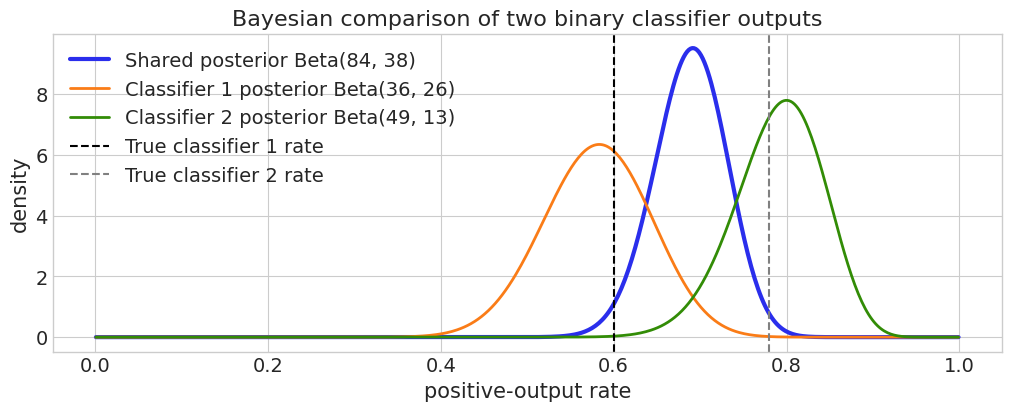

In [11]:
grid = np.linspace(0.001, 0.999, 500)
plt.figure(figsize=(10, 4))
plt.plot(grid, beta_dist.pdf(grid, pooled_alpha, pooled_beta), label=f"Shared posterior Beta({pooled_alpha}, {pooled_beta})", linewidth=3)
plt.plot(grid, beta_dist.pdf(grid, alpha_1, beta_1), label=f"Classifier 1 posterior Beta({alpha_1}, {beta_1})", linewidth=2)
plt.plot(grid, beta_dist.pdf(grid, alpha_2, beta_2), label=f"Classifier 2 posterior Beta({alpha_2}, {beta_2})", linewidth=2)
plt.axvline(theta_1_true, color="black", linestyle="--", label="True classifier 1 rate")
plt.axvline(theta_2_true, color="gray", linestyle="--", label="True classifier 2 rate")
plt.xlabel("positive-output rate")
plt.ylabel("density")
plt.title("Bayesian comparison of two binary classifier outputs")
plt.legend();

### Reading the classifier comparison

The shared model is the "indistinguishable classifiers" story: both classifiers are forced to share one positive-output rate.
The separate model is the "distinguishable classifiers" story: each classifier gets its own rate and can explain asymmetric outputs directly.
The posterior probability that classifier 2 is more positive than classifier 1 is a direct effect statement; the Bayes factor compares the two model stories.

If the Bayes factor is comfortably above 1, the separate model is supported; if it stays near 1, the pooled story is enough.

### Exercises

1. Change the simulated rates so the two classifiers are closer together. How quickly does the Bayes factor move back toward 1?
2. Keep the rates fixed but halve the sample sizes. What happens to the posterior overlap?


### (Optional) Dirichlet multi-class extension

The Dirichlet distribution is the multi-class analogue of Beta: it lives on probability vectors whose components are non-negative and sum to 1.
That makes it a natural prior for three-class outputs. As in the binary case, posterior updating is just prior counts plus observed counts.


In [12]:
# Multi-class version of the same distinguishable-versus-indistinguishable question.
multi_rng = np.random.default_rng(SEED + 103)
posterior_rng_multi = np.random.default_rng(SEED + 104)

class_names = ["A", "B", "C"]
# we have not only 2 classifiers, but also 3 classes (A, B, C) that the classifiers can assign to each observation. This adds complexity to the problem because we now need to consider the distribution of probabilities across multiple classes for each classifier, rather than just a single positive-output rate. The question of whether the classifiers are distinguishable or indistinguishable now involves comparing the entire probability distributions over the three classes for each classifier, rather than just a single parameter. This is why we need to use a Dirichlet distribution (the multivariate generalization of the Beta distribution) to model the probabilities for each class and compare
k = len(class_names)
multi_n_1 = 90 # number of observations for classifier 1
multi_n_2 = 90 # number of observations for classifier 2
multi_p_1_true = np.array([0.55, 0.30, 0.15]) # The true probability distribution over the three classes for classifier 1. In a real experiment, this would be unknown and what we're trying to infer by Bayesian comparison of the two classifiers.
multi_p_2_true = np.array([0.35, 0.40, 0.25]) # The true probability distribution over the three classes for classifier 2. In a real experiment, this would be unknown and what we're trying to infer by Bayesian comparison of the two classifiers.

# GENERATE SYNTHETIC DATA FOR TWO CLASSIFIERS WITH MULTI-CLASS OUTPUTS
labels_1 = multi_rng.choice(k, size=multi_n_1, p=multi_p_1_true)
labels_2 = multi_rng.choice(k, size=multi_n_2, p=multi_p_2_true)

In [13]:
multi_counts_1 = np.bincount(labels_1, minlength=k)
multi_counts_2 = np.bincount(labels_2, minlength=k)
multi_pooled_counts = multi_counts_1 + multi_counts_2

# PRIORS: We will use a non-informative Dirichlet prior for both classifiers, which means we have no prior preference for any particular probability distribution over the classes before seeing the data. This allows us to let the data speak for itself in updating our beliefs about the classifiers' performance across the multiple classes.
multi_prior_alpha = np.ones(k)

# POSTERIOR: The parameters of the posterior Dirichlet distribution for each classifier are updated based on the observed counts of class assignments
    # Shared model: one probability vector for both classifiers.
multi_shared_alpha = multi_prior_alpha + multi_pooled_counts
    # Separate model: one probability vector per classifier.
multi_alpha_1 = multi_prior_alpha + multi_counts_1
multi_alpha_2 = multi_prior_alpha + multi_counts_2

In [14]:
draws_1 = posterior_rng_multi.dirichlet(multi_alpha_1, size=50_000)
draws_2 = posterior_rng_multi.dirichlet(multi_alpha_2, size=50_000)

prob_2_gt_1_multi = np.mean(np.argmax(draws_2, axis=1) == 0) / np.mean(np.argmax(draws_1, axis=1) == 0)
# prob_2_gt_1_multi is the probability that classifier 2 is better than classifier
# in terms of correctly classifying class 0 (the first class) based on the posterior distributions over the classes for each classifier.
# We compute this by taking the mean of the samples from the posterior distribution of classifier 2
prob_2_gt_1_multi

np.float64(0.9712154493867838)

In [15]:
def log_marginal_dirichlet_multinomial(counts, alpha):
    """Computes the log marginal likelihood of a Dirichlet-multinomial model given observed counts and Dirichlet parameters (alpha). This is used to compute the evidence for each model in the Bayes factor calculation."""
    counts = np.asarray(counts, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
    return (
        lgamma(alpha.sum())
        - lgamma(alpha.sum() + counts.sum())
        + sum(lgamma(a + c) - lgamma(a) for a, c in zip(alpha, counts))
    )

log_evidence_shared = log_marginal_dirichlet_multinomial(multi_pooled_counts, multi_prior_alpha)
log_evidence_separate = (
    log_marginal_dirichlet_multinomial(multi_counts_1, multi_prior_alpha)
    + log_marginal_dirichlet_multinomial(multi_counts_2, multi_prior_alpha)
)
log_bayes_factor = log_evidence_separate - log_evidence_shared
bayes_factor = np.exp(log_bayes_factor)

In [16]:
class_summary = pd.DataFrame(
    {
        "clf 1 observed": multi_counts_1 / multi_n_1,
        "clf 2 observed": multi_counts_2 / multi_n_2,
        "shared observed": multi_pooled_counts / (multi_n_1 + multi_n_2),
        "clf 1 posterior mean": multi_alpha_1 / multi_alpha_1.sum(),
        "clf 2 posterior mean": multi_alpha_2 / multi_alpha_2.sum(),
        "shared posterior mean": multi_shared_alpha / multi_shared_alpha.sum(),
    },
    index=class_names,
)

display(class_summary.round(3))
print(
    {
        "P(classifier 2 assigns more mass to A | data)": float(np.mean(draws_2[:, 0] > draws_1[:, 0])),
        "Bayes factor separate / shared": bayes_factor,
        "log Bayes factor": log_bayes_factor,
    }
)


,clf 1 observed,clf 2 observed,shared observed,clf 1 posterior mean,clf 2 posterior mean,shared posterior mean
A,0.478,0.422,0.450,0.473,0.419,0.448
B,0.367,0.322,0.344,0.366,0.323,0.344
C,0.156,0.256,0.206,0.161,0.258,0.208


{'P(classifier 2 assigns more mass to A | data)': 0.22706, 'Bayes factor separate / shared': np.float64(0.1862815332315452), 'log Bayes factor': -1.6804961301119192}


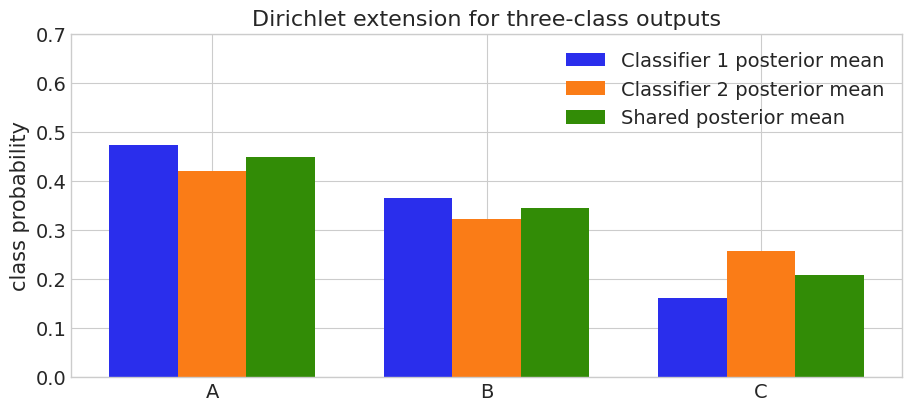

In [17]:
x = np.arange(k)
width = 0.25
plt.figure(figsize=(9, 4))
plt.bar(x - width, multi_alpha_1 / multi_alpha_1.sum(), width, label="Classifier 1 posterior mean")
plt.bar(x, multi_alpha_2 / multi_alpha_2.sum(), width, label="Classifier 2 posterior mean")
plt.bar(x + width, multi_shared_alpha / multi_shared_alpha.sum(), width, label="Shared posterior mean")
plt.xticks(x, class_names)
plt.ylim(0, 0.7)
plt.ylabel("class probability")
plt.title("Dirichlet extension for three-class outputs")
plt.legend();

### Exercises

1. Change the amount of simulated data and comment on the results.
